In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment is ready!")

Environment is ready!


In [2]:
df = pd.read_csv("../data/raw/Unemployment in America Per Us State.csv ")

first i need to check if this dataset is approperiate for the assigned task

In [3]:
df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,1,Alabama,1976,1,"2,605,000","1,486,509",57.1,"1,387,606",53.3,"98,903",6.7
1,2,Alaska,1976,1,"232,000","160,709",69.3,"149,226",64.3,"11,483",7.1
2,4,Arizona,1976,1,"1,621,000","963,980",59.5,"865,261",53.4,"98,719",10.2
3,5,Arkansas,1976,1,"1,536,000","889,912",57.9,"825,233",53.7,"64,679",7.3
4,6,California,1976,1,"15,621,000","9,770,553",62.5,"8,873,133",56.8,"897,420",9.2


In [4]:
df.shape

(31747, 11)

In [5]:
df.columns

Index(['FIPS Code', 'State/Area', 'Year', 'Month',
       'Total Civilian Non-Institutional Population in State/Area',
       'Total Civilian Labor Force in State/Area',
       'Percent (%) of State/Area's Population',
       'Total Employment in State/Area',
       'Percent (%) of Labor Force Employed in State/Area',
       'Total Unemployment in State/Area',
       'Percent (%) of Labor Force Unemployed in State/Area'],
      dtype='str')

In [6]:
# Display the earliest and latest year in the dataset.
# This tells us the historical time span and whether the dataset
# covers the period needed for the COVID-19 analysis.
print("Earliest year:", df["Year"].min())
print("Latest year:", df["Year"].max())

Earliest year: 1976
Latest year: 2025


PERFECT, the dataset covers covid-19 period

In [7]:
# Display all unique years in the dataset.
# This lets see whether the years form a continuous historical period
# and helps identify any unusual year values.
df["Year"].unique()

array([1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997,
       1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023, 2024, 2025])

great, this dataset will allow me to investigate long term trends, pre covid period, covid shock, post covid and state deffirences

In [8]:
# Display all unique geographic areas in the dataset.
# This tells us exactly which locations are represented
# and whether the dataset contains only U.S. states or also other areas.
df["State/Area"].unique()

<StringArray>
[             'Alabama',               'Alaska',              'Arizona',
             'Arkansas',           'California',   'Los Angeles County',
             'Colorado',          'Connecticut',             'Delaware',
 'District of Columbia',              'Florida',              'Georgia',
               'Hawaii',                'Idaho',             'Illinois',
              'Indiana',                 'Iowa',               'Kansas',
             'Kentucky',            'Louisiana',                'Maine',
             'Maryland',        'Massachusetts',             'Michigan',
            'Minnesota',          'Mississippi',             'Missouri',
              'Montana',             'Nebraska',               'Nevada',
        'New Hampshire',           'New Jersey',           'New Mexico',
             'New York',        'New York city',       'North Carolina',
         'North Dakota',                 'Ohio',             'Oklahoma',
               'Oregon',         'Pen

there is a mix of states, cities(NYC), counties(LA), and federal district(district of columbia)

In [9]:
# Count the number of observations for each geographic area.
# This helps us determine whether every area has a similar
# monthly history or whether some areas have different coverage.
df["State/Area"].value_counts()

State/Area
Alabama                 599
Alaska                  599
Arizona                 599
Arkansas                599
California              599
Los Angeles County      599
Colorado                599
Connecticut             599
Delaware                599
District of Columbia    599
Florida                 599
Georgia                 599
Hawaii                  599
Idaho                   599
Illinois                599
Indiana                 599
Iowa                    599
Kansas                  599
Kentucky                599
Louisiana               599
Maine                   599
Maryland                599
Massachusetts           599
Michigan                599
Minnesota               599
Mississippi             599
Missouri                599
Montana                 599
Nebraska                599
Nevada                  599
New Hampshire           599
New Jersey              599
New Mexico              599
New York                599
New York city           599
North Car

In [10]:
# Count how many observations exist for each year.
# This helps us see whether the dataset contains a complete
# monthly history for every year or whether some periods are missing.
df["Year"].value_counts().sort_index()

Year
1976    636
1977    636
1978    636
1979    636
1980    636
1981    636
1982    636
1983    636
1984    636
1985    636
1986    636
1987    636
1988    636
1989    636
1990    636
1991    636
1992    636
1993    636
1994    636
1995    636
1996    636
1997    636
1998    636
1999    636
2000    636
2001    636
2002    636
2003    636
2004    636
2005    636
2006    636
2007    636
2008    636
2009    636
2010    636
2011    636
2012    636
2013    636
2014    636
2015    636
2016    636
2017    636
2018    636
2019    636
2020    636
2021    636
2022    636
2023    636
2024    636
2025    583
Name: count, dtype: int64

In [11]:
# Display the months available in 2025.
# This confirms exactly where the dataset's time coverage ends
# and helps us determine whether 2025 is simply a partial year.
df.loc[df["Year"] == 2025, "Month"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

THIS EXPLAINS WHY 2025's VALUE IS DIFFERENT FROM THE OTHER YEARS
BY THIS IT IS CONFIRMED THAT IS DATASET IS INDDED SUITABLE

NOW MOVING TO ACTUAL PROJECT

In [12]:
# Display the data type of every column.
# This helps us identify columns whose stored data type
# does not match the type of information they contain.
df.dtypes

FIPS Code                                                    int64
State/Area                                                     str
Year                                                         int64
Month                                                        int64
Total Civilian Non-Institutional Population in State/Area      str
Total Civilian Labor Force in State/Area                       str
Percent (%) of State/Area's Population                         str
Total Employment in State/Area                                 str
Percent (%) of Labor Force Employed in State/Area              str
Total Unemployment in State/Area                               str
Percent (%) of Labor Force Unemployed in State/Area            str
dtype: object

In [13]:
# Display several values from the Total Unemployment column.
# This lets us inspect the actual format of the values
# before deciding how they should be converted.
df["Total Unemployment in State/Area"].head(10)

0     98,903   
1     11,483   
2     98,719   
3     64,679   
4    897,420   
5    298,871   
6     71,140   
7    139,484   
8     20,941   
9     29,410   
Name: Total Unemployment in State/Area, dtype: str

In [14]:
# Display the Python type of the first value in the column.
# This confirms whether the individual values are actually strings
# and helps us understand why pandas assigned the column a string dtype.
type(df["Total Unemployment in State/Area"].iloc[0])

str

In [15]:
# Store the columns that contain numerical data but are currently
# stored as strings. Keeping them in a list makes the cleaning step
# easier to manage and avoids repeating the column names.
numeric_columns = [
    "Total Civilian Non-Institutional Population in State/Area",
    "Total Civilian Labor Force in State/Area",
    "Percent (%) of State/Area's Population",
    "Total Employment in State/Area",
    "Percent (%) of Labor Force Employed in State/Area",
    "Total Unemployment in State/Area",
    "Percent (%) of Labor Force Unemployed in State/Area"
]

In [16]:
# Count how many "–" values exist in each numerical column.
# This tells us which columns use the special dash value
# and how frequently it occurs.
for column in numeric_columns:
    count = (df[column] == "–").sum()
    if count > 0:
        print(column, ":", count)

Total Civilian Non-Institutional Population in State/Area : 53
Total Civilian Labor Force in State/Area : 53
Percent (%) of State/Area's Population : 53
Total Employment in State/Area : 53
Percent (%) of Labor Force Employed in State/Area : 53
Total Unemployment in State/Area : 53
Percent (%) of Labor Force Unemployed in State/Area : 53


In [17]:
# Find the rows where the unemployment value is represented by "–".
# Inspecting these rows helps us determine which time period
# the special missing-value marker belongs to.
df[df["Total Unemployment in State/Area"] == "–"][
    ["State/Area", "Year", "Month", "Total Unemployment in State/Area"]
]

,State/Area,Year,Month,Total Unemployment in State/Area
31641,Alabama,2025,10,–
31642,Alaska,2025,10,–
31643,Arizona,2025,10,–
31644,Arkansas,2025,10,–
31645,California,2025,10,–
31646,Los Angeles County,2025,10,–
31647,Colorado,2025,10,–
31648,Connecticut,2025,10,–
31649,Delaware,2025,10,–
31650,District of Columbia,2025,10,–


In [18]:
# Display the identifying information for the October 2025 observations.
# This confirms that the geographic and time information is still present
# even though the numerical measurements are represented by "–".
df.loc[
    (df["Year"] == 2025) & (df["Month"] == 10),
    ["FIPS Code", "State/Area", "Year", "Month"]
]

,FIPS Code,State/Area,Year,Month
31641,1,Alabama,2025,10
31642,2,Alaska,2025,10
31643,4,Arizona,2025,10
31644,5,Arkansas,2025,10
31645,6,California,2025,10
31646,37,Los Angeles County,2025,10
31647,8,Colorado,2025,10
31648,9,Connecticut,2025,10
31649,10,Delaware,2025,10
31650,11,District of Columbia,2025,10


In [19]:
# Replace the dataset's special missing-value marker "–" with NaN.
# NaN is pandas' standard representation for a missing numerical value,
# which allows the columns to be converted to numeric types correctly.
df[numeric_columns] = df[numeric_columns].replace("–", float("nan"))

In [20]:
# Count the missing values in each numerical column.
# This verifies that the 53 special "–" values were converted
# into proper missing values.
df[numeric_columns].isna().sum()

Total Civilian Non-Institutional Population in State/Area    53
Total Civilian Labor Force in State/Area                     53
Percent (%) of State/Area's Population                       53
Total Employment in State/Area                               53
Percent (%) of Labor Force Employed in State/Area            53
Total Unemployment in State/Area                             53
Percent (%) of Labor Force Unemployed in State/Area          53
dtype: int64

In [21]:
# Remove thousands separators from the values and convert the affected
# columns from strings to numeric values.
# The "–" values have already been converted to NaN, so pandas
# can now represent the columns as numerical data.
for column in numeric_columns:
    df[column] = df[column].str.replace(",", "", regex=False).astype(float)

In [22]:
# Check the data types after conversion.
# The seven previously string-based numerical columns should now
# be stored as floating-point numerical data.
df[numeric_columns].dtypes

Total Civilian Non-Institutional Population in State/Area    float64
Total Civilian Labor Force in State/Area                     float64
Percent (%) of State/Area's Population                       float64
Total Employment in State/Area                               float64
Percent (%) of Labor Force Employed in State/Area            float64
Total Unemployment in State/Area                             float64
Percent (%) of Labor Force Unemployed in State/Area          float64
dtype: object

In [23]:
# Count missing values in every column.
# This helps us identify whether the dataset contains
# any missing data beyond the 53 October 2025 observations.
df.isna().sum()

FIPS Code                                                     0
State/Area                                                    0
Year                                                          0
Month                                                         0
Total Civilian Non-Institutional Population in State/Area    53
Total Civilian Labor Force in State/Area                     53
Percent (%) of State/Area's Population                       53
Total Employment in State/Area                               53
Percent (%) of Labor Force Employed in State/Area            53
Total Unemployment in State/Area                             53
Percent (%) of Labor Force Unemployed in State/Area          53
dtype: int64

In [24]:
# Count rows that are exact duplicates of another row.
# This checks whether the dataset contains completely repeated observations.
df.duplicated().sum()

np.int64(0)

In [25]:
# Check whether the same geographic area appears more than once
# for the same year and month.
# Each State/Area + Year + Month combination should represent
# one monthly observation.
duplicate_keys = df.duplicated(
    subset=["State/Area", "Year", "Month"]
)

duplicate_keys.sum()

np.int64(0)

In [26]:
# Display all unique geographic entities in the dataset.
# This lets us inspect the State/Area labels before deciding
# whether any geographic values need cleaning.
df["State/Area"].unique()

<StringArray>
[             'Alabama',               'Alaska',              'Arizona',
             'Arkansas',           'California',   'Los Angeles County',
             'Colorado',          'Connecticut',             'Delaware',
 'District of Columbia',              'Florida',              'Georgia',
               'Hawaii',                'Idaho',             'Illinois',
              'Indiana',                 'Iowa',               'Kansas',
             'Kentucky',            'Louisiana',                'Maine',
             'Maryland',        'Massachusetts',             'Michigan',
            'Minnesota',          'Mississippi',             'Missouri',
              'Montana',             'Nebraska',               'Nevada',
        'New Hampshire',           'New Jersey',           'New Mexico',
             'New York',        'New York city',       'North Carolina',
         'North Dakota',                 'Ohio',             'Oklahoma',
               'Oregon',         'Pen

In [27]:
#check how many unique geographic entities exist for each FIPS Code.
df.groupby("FIPS Code")["State/Area"].nunique().max()

np.int64(2)

In [28]:
df.groupby("FIPS Code")["State/Area"].unique()

FIPS Code
1                                   [Alabama]
2                                    [Alaska]
4                                   [Arizona]
5                                  [Arkansas]
6                                [California]
8                                  [Colorado]
9                               [Connecticut]
10                                 [Delaware]
11                     [District of Columbia]
12                                  [Florida]
13                                  [Georgia]
15                                   [Hawaii]
16                                    [Idaho]
17                                 [Illinois]
18                                  [Indiana]
19                                     [Iowa]
20                                   [Kansas]
21                                 [Kentucky]
22                                [Louisiana]
23                                    [Maine]
24                                 [Maryland]
25                      

In [29]:
df[df["FIPS Code"] == 37][["FIPS Code", "State/Area", "Year", "Month"]].head()

,FIPS Code,State/Area,Year,Month
5,37,Los Angeles County,1976,1
35,37,North Carolina,1976,1
58,37,Los Angeles County,1976,2
88,37,North Carolina,1976,2
111,37,Los Angeles County,1976,3


In [30]:
df[df["State/Area"] == "Los Angeles County"]["FIPS Code"].unique()

array([37])

In [31]:
# Compare the two geographic entities that currently share FIPS Code 37.
# This helps us confirm whether the same identifier is consistently being
# used for both areas throughout the dataset.
df[df["State/Area"].isin(["Los Angeles County", "North Carolina"])][
    ["FIPS Code", "State/Area", "Year", "Month"]
].head(10)

,FIPS Code,State/Area,Year,Month
5,37,Los Angeles County,1976,1
35,37,North Carolina,1976,1
58,37,Los Angeles County,1976,2
88,37,North Carolina,1976,2
111,37,Los Angeles County,1976,3
141,37,North Carolina,1976,3
164,37,Los Angeles County,1976,4
194,37,North Carolina,1976,4
217,37,Los Angeles County,1976,5
247,37,North Carolina,1976,5


In [32]:
# Display the first few geographic records with their FIPS codes.
# This lets us see how the dataset assigns identifiers to the
# different geographic entities and whether there is a clear pattern.
df[["FIPS Code", "State/Area"]].drop_duplicates().sort_values("FIPS Code")

,FIPS Code,State/Area
0,1,Alabama
1,2,Alaska
2,4,Arizona
3,5,Arkansas
4,6,California
6,8,Colorado
7,9,Connecticut
8,10,Delaware
9,11,District of Columbia
10,12,Florida


In [33]:
# Check whether each State/Area has exactly one FIPS Code.
# This is the reverse of our previous check:
# instead of asking whether one FIPS code maps to multiple areas,
# we ask whether one geographic area maps to multiple FIPS codes.
df.groupby("State/Area")["FIPS Code"].nunique().max()

np.int64(1)

Data Cleaning Progress So Far
1. Dataset structure
Dataset size: 31,747 rows × 11 columns
Coverage: 1976–2025
2025 contains January–November
53 geographic entities
Each geographic entity has 599 observations
2. Data types
Identified 7 numerical columns incorrectly stored as strings.
Values such as "98,903" were stored as strings because of thousands separators.
Successfully converted all 7 columns to float64.
3. Special missing values
Found the special value – in all 7 numerical columns.
There were 53 occurrences per column.
All 53 occurred in October 2025, one for each geographic entity.
Replaced – with NaN rather than zero.
Confirmed there are no other missing values.
4. Duplicate observations
Exact duplicate rows: 0
Duplicate State/Area + Year + Month combinations: 0
Therefore, no duplicate records need to be removed.
5. Geographic validation
Found 53 unique geographic entities.
The dataset contains mixed geographic granularity:
States
District of Columbia
Los Angeles County
New York city
Found a FIPS inconsistency:
FIPS Code 37 → North Carolina
FIPS Code 37 → Los Angeles County
Confirmed this conflict is systematic throughout the dataset.
Confirmed each State/Area has exactly one FIPS code.
Therefore, we have not modified the FIPS values or deleted any geographic observations.
Current conclusion

The dataset has several real-world data-quality issues, but so far we have handled only the issues that were supported by evidence. The data is now ready for the next validation stage: numerical values and logical relationships.

In [34]:
# Check whether any numerical column contains negative values.
# Negative population, labor force, employment, unemployment,
# or percentage values would indicate a potential data-quality issue.
(df[numeric_columns] < 0).sum()

Total Civilian Non-Institutional Population in State/Area    0
Total Civilian Labor Force in State/Area                     0
Percent (%) of State/Area's Population                       0
Total Employment in State/Area                               0
Percent (%) of Labor Force Employed in State/Area            0
Total Unemployment in State/Area                             0
Percent (%) of Labor Force Unemployed in State/Area          0
dtype: int64

In [35]:
# Check whether the unemployment rate contains values
# outside the possible range of 0% to 100%.
# Values below 0% or above 100% would indicate invalid data.
unemployment_rate = "Percent (%) of Labor Force Unemployed in State/Area"

df[unemployment_rate].agg(["min", "max"])

min     1.7
max    30.5
Name: Percent (%) of Labor Force Unemployed in State/Area, dtype: float64

In [36]:
#Check Labor Force = Employment + Unemployment
df["Calculated Labor Force"] = (
    df["Total Employment in State/Area"]
    + df["Total Unemployment in State/Area"]
)

df["Labor Force Difference"] = (
    df["Total Civilian Labor Force in State/Area"]
    - df["Calculated Labor Force"]
)

df["Labor Force Difference"].describe()

count    31694.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Labor Force Difference, dtype: float64

In [37]:
#validate the unemployment percentage
df["Calculated Unemployment Rate"] = (
    df["Total Unemployment in State/Area"]
    / df["Total Civilian Labor Force in State/Area"]
) * 100

df["Unemployment Rate Difference"] = (
    df["Percent (%) of Labor Force Unemployed in State/Area"]
    - df["Calculated Unemployment Rate"]
)

df["Unemployment Rate Difference"].describe()

count    31694.000000
mean        -0.000140
std          0.028937
min         -0.049999
25%         -0.025215
50%         -0.000276
75%          0.024829
max          0.049995
Name: Unemployment Rate Difference, dtype: float64

In [38]:
df["Calculated Employment Rate"] = (
    df["Total Employment in State/Area"]
    / df["Total Civilian Labor Force in State/Area"]
) * 100

df["Employment Rate Difference"] = (
    df["Percent (%) of Labor Force Employed in State/Area"]
    - df["Calculated Employment Rate"]
)

df["Employment Rate Difference"].describe()

count    31694.000000
mean       -32.597793
std          3.899177
min        -45.529001
25%        -35.138018
50%        -32.151453
75%        -29.989724
max        -23.391299
Name: Employment Rate Difference, dtype: float64

In [39]:
df[
    [
        "Total Civilian Labor Force in State/Area",
        "Total Employment in State/Area",
        "Total Unemployment in State/Area",
        "Percent (%) of Labor Force Employed in State/Area",
        "Percent (%) of Labor Force Unemployed in State/Area"
    ]
].head(10)

,Total Civilian Labor Force in State/Area,Total Employment in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Employed in State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,1486509.0,1387606.0,98903.0,53.3,6.7
1,160709.0,149226.0,11483.0,64.3,7.1
2,963980.0,865261.0,98719.0,53.4,10.2
3,889912.0,825233.0,64679.0,53.7,7.3
4,9770553.0,8873133.0,897420.0,56.8,9.2
5,3371503.0,3072632.0,298871.0,58.3,8.9
6,1232215.0,1161075.0,71140.0,63.4,5.8
7,1440708.0,1301224.0,139484.0,57.9,9.7
8,261577.0,240636.0,20941.0,57.7,8.0
9,334885.0,305475.0,29410.0,58.7,8.8


In [40]:
df[
    [
        "Percent (%) of Labor Force Employed in State/Area",
        "Calculated Employment Rate",
        "Employment Rate Difference"
    ]
].head(10)

,Percent (%) of Labor Force Employed in State/Area,Calculated Employment Rate,Employment Rate Difference
0,53.3,93.346626,-40.046626
1,64.3,92.854787,-28.554787
2,53.4,89.759227,-36.359227
3,53.7,92.731978,-39.031978
4,56.8,90.815054,-34.015054
5,58.3,91.135378,-32.835378
6,63.4,94.226657,-30.826657
7,57.9,90.318371,-32.418371
8,57.7,91.994327,-34.294327
9,58.7,91.217881,-32.517881


In [41]:
df[
    [
        "Total Civilian Non-Institutional Population in State/Area",
        "Total Civilian Labor Force in State/Area",
        "Total Employment in State/Area",
        "Total Unemployment in State/Area",
        "Percent (%) of State/Area's Population",
        "Percent (%) of Labor Force Employed in State/Area",
        "Percent (%) of Labor Force Unemployed in State/Area"
    ]
].head(10)

,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Total Employment in State/Area,Total Unemployment in State/Area,Percent (%) of State/Area's Population,Percent (%) of Labor Force Employed in State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,2605000.0,1486509.0,1387606.0,98903.0,57.1,53.3,6.7
1,232000.0,160709.0,149226.0,11483.0,69.3,64.3,7.1
2,1621000.0,963980.0,865261.0,98719.0,59.5,53.4,10.2
3,1536000.0,889912.0,825233.0,64679.0,57.9,53.7,7.3
4,15621000.0,9770553.0,8873133.0,897420.0,62.5,56.8,9.2
5,5273000.0,3371503.0,3072632.0,298871.0,63.9,58.3,8.9
6,1832000.0,1232215.0,1161075.0,71140.0,67.3,63.4,5.8
7,2248000.0,1440708.0,1301224.0,139484.0,64.1,57.9,9.7
8,417000.0,261577.0,240636.0,20941.0,62.7,57.7,8.0
9,520000.0,334885.0,305475.0,29410.0,64.4,58.7,8.8


In [42]:
df["Calculated Participation Rate"] = (
    df["Total Civilian Labor Force in State/Area"]
    / df["Total Civilian Non-Institutional Population in State/Area"]
) * 100

df["Participation Rate Difference"] = (
    df["Percent (%) of State/Area's Population"]
    - df["Calculated Participation Rate"]
)

df["Participation Rate Difference"].describe()


count    31694.000000
mean         0.000128
std          0.028817
min         -0.049998
25%         -0.024691
50%          0.000105
75%          0.025006
max          0.050000
Name: Participation Rate Difference, dtype: float64

In [43]:
df["Participation Rate Difference"].abs().max()

np.float64(0.05000000000000426)

In [44]:
df["Calculated Employment-to-Population Rate"] = (
    df["Total Employment in State/Area"]
    / df["Total Civilian Non-Institutional Population in State/Area"]
) * 100

df["Employment-to-Population Difference"] = (
    df["Percent (%) of Labor Force Employed in State/Area"]
    - df["Calculated Employment-to-Population Rate"]
)

df["Employment-to-Population Difference"].describe()

count    31694.000000
mean         0.000083
std          0.028856
min         -0.049995
25%         -0.024992
50%          0.000412
75%          0.024951
max          0.050000
Name: Employment-to-Population Difference, dtype: float64

In [45]:
df["Employment-to-Population Difference"].abs().max()

np.float64(0.04999999999999716)

## Numerical and Logical Validation

After cleaning the numerical columns, the dataset was validated for numerical accuracy and logical consistency.

### 1. Negative Values
- Checked the numerical columns for negative values.
- No negative values were found.

### 2. Unemployment Rate Range
- Checked `Percent (%) of Labor Force Unemployed in State/Area`.
- Minimum: **1.7%**
- Maximum: **30.5%**
- All values are within a plausible percentage range.

### 3. Labor Force Consistency
Verified that:

**Labor Force = Employment + Unemployment**

- Checked **31,694 complete observations**.
- Difference was exactly **0** for every observation.
- The remaining 53 rows contain the previously identified `NaN` values from October 2025.

### 4. Unemployment Rate Consistency
Verified:

**Unemployment Rate = Unemployment ÷ Labor Force × 100**

- Differences between reported and calculated values ranged from approximately **−0.05 to +0.05 percentage points**.
- This is consistent with the original percentages being rounded to one decimal place.
- No inconsistencies were detected.

### 5. Labor-Force Participation Rate
Verified:

**Participation Rate = Labor Force ÷ Civilian Non-Institutional Population × 100**

- Differences ranged from approximately **−0.05 to +0.05 percentage points**.
- Results are consistent with one-decimal-place rounding.
- No inconsistencies were detected.

### 6. Employment-to-Population Ratio
Verified:

**Employment-to-Population Ratio = Employment ÷ Civilian Non-Institutional Population × 100**

- Differences ranged from approximately **−0.05 to +0.05 percentage points**.
- Results are consistent with one-decimal-place rounding.
- No inconsistencies were detected.

### Conclusion

The numerical and logical validation found **no data-quality problems requiring modification**. The counts and percentages are internally consistent, and the small percentage differences are explained by rounding.

**Next validation stage:** Date and temporal validation.

In [46]:
df["Month"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [47]:
df["Month"].value_counts().sort_index()

Month
1     2650
2     2650
3     2650
4     2650
5     2650
6     2650
7     2650
8     2650
9     2650
10    2650
11    2650
12    2597
Name: count, dtype: int64

In [48]:
df.groupby("Year")["Month"].agg(["min", "max", "count"]).tail(10)

,min,max,count
Year,,,
2016,1,12,636
2017,1,12,636
2018,1,12,636
2019,1,12,636
2020,1,12,636
2021,1,12,636
2022,1,12,636
2023,1,12,636
2024,1,12,636


In [49]:
df[df["Year"] == 2025]["Month"].value_counts().sort_index()

Month
1     53
2     53
3     53
4     53
5     53
6     53
7     53
8     53
9     53
10    53
11    53
Name: count, dtype: int64

last two code blocks confirm that December's count is different than the rest of the months because December 2025 is not recorded in all 53 areas

In [50]:
# Count the number of observations for each geographic entity.
# Every entity should have exactly 599 observations:
# 49 complete years × 12 months + 11 months from 2025.
observations_per_area = df.groupby("State/Area").size()

observations_per_area.value_counts()

599    53
Name: count, dtype: int64

In [51]:
# Count the number of distinct months available for each
# geographic entity in each year.
#
# From 1976–2024, every entity should have 12 months.
# In 2025, every entity should have 11 months (January–November).
months_per_area_year = (
    df.groupby(["State/Area", "Year"])["Month"]
      .nunique()
)

# Display the distribution of the number of months per
# geographic entity-year combination.
months_per_area_year.value_counts().sort_index()

Month
11      53
12    2597
Name: count, dtype: int64

In [52]:
# Display all unique geographic labels in the dataset.
# This helps us identify spelling differences, extra spaces,
# inconsistent capitalization, or unexpected geographic entities.
df["State/Area"].unique()

<StringArray>
[             'Alabama',               'Alaska',              'Arizona',
             'Arkansas',           'California',   'Los Angeles County',
             'Colorado',          'Connecticut',             'Delaware',
 'District of Columbia',              'Florida',              'Georgia',
               'Hawaii',                'Idaho',             'Illinois',
              'Indiana',                 'Iowa',               'Kansas',
             'Kentucky',            'Louisiana',                'Maine',
             'Maryland',        'Massachusetts',             'Michigan',
            'Minnesota',          'Mississippi',             'Missouri',
              'Montana',             'Nebraska',               'Nevada',
        'New Hampshire',           'New Jersey',           'New Mexico',
             'New York',        'New York city',       'North Carolina',
         'North Dakota',                 'Ohio',             'Oklahoma',
               'Oregon',         'Pen

In [53]:
# Check whether any State/Area labels contain leading or trailing spaces.
# A result of 0 means that the geographic labels are already trimmed.
(df["State/Area"] != df["State/Area"].str.strip()).sum()

np.int64(0)

In [54]:
# Count observations for each geographic entity.
# Every entity should have exactly 599 observations.
df["State/Area"].value_counts()

State/Area
Alabama                 599
Alaska                  599
Arizona                 599
Arkansas                599
California              599
Los Angeles County      599
Colorado                599
Connecticut             599
Delaware                599
District of Columbia    599
Florida                 599
Georgia                 599
Hawaii                  599
Idaho                   599
Illinois                599
Indiana                 599
Iowa                    599
Kansas                  599
Kentucky                599
Louisiana               599
Maine                   599
Maryland                599
Massachusetts           599
Michigan                599
Minnesota               599
Mississippi             599
Missouri                599
Montana                 599
Nebraska                599
Nevada                  599
New Hampshire           599
New Jersey              599
New Mexico              599
New York                599
New York city           599
North Car

In [55]:
# Check how many unique FIPS codes are associated with each geographic entity.
# Ideally, every State/Area should have exactly one FIPS code.
fips_per_area = df.groupby("State/Area")["FIPS Code"].nunique()

fips_per_area.value_counts()

FIPS Code
1    53
Name: count, dtype: int64

In [56]:
# Remove temporary columns created only for validation.
# These columns are not part of the original dataset and are
# no longer needed after completing the consistency checks.
validation_columns = [
    "Calculated Labor Force",
    "Labor Force Difference",
    "Calculated Unemployment Rate",
    "Unemployment Rate Difference",
    "Calculated Employment Rate",
    "Employment Rate Difference",
    "Calculated Participation Rate",
    "Participation Rate Difference",
    "Calculated Employment-to-Population Rate",
    "Employment-to-Population Difference"
]

df.drop(columns=validation_columns, inplace=True)

In [57]:
# Find FIPS codes that are associated with more than one geographic entity.
# This identifies potential inconsistencies in the geographic identifiers.
areas_per_fips = df.groupby("FIPS Code")["State/Area"].nunique()

areas_per_fips[areas_per_fips > 1]

FIPS Code
37    2
Name: State/Area, dtype: int64

In [58]:
# Count missing values in every column.
# This gives us a final overview of missing data after cleaning.
df.isna().sum()

FIPS Code                                                     0
State/Area                                                    0
Year                                                          0
Month                                                         0
Total Civilian Non-Institutional Population in State/Area    53
Total Civilian Labor Force in State/Area                     53
Percent (%) of State/Area's Population                       53
Total Employment in State/Area                               53
Percent (%) of Labor Force Employed in State/Area            53
Total Unemployment in State/Area                             53
Percent (%) of Labor Force Unemployed in State/Area          53
dtype: int64

In [59]:
# Count the total number of missing values across the entire dataset.
# We expect 53 missing values in each of the 7 affected numerical columns,
# and no missing values in the other columns.
df.isna().sum().sum()

np.int64(371)

# Data Cleaning and Validation

The dataset contains **31,747 observations and 11 columns**, covering **53 geographic entities** from **1976 to 2025**. The data was systematically inspected and validated before beginning exploratory analysis.

## 1. Dataset Structure

- **Rows:** 31,747
- **Columns:** 11
- **Time period:** 1976–2025
- **Geographic entities:** 53
- **Observations per geographic entity:** 599
- **2025 coverage:** January–November

The dataset contains U.S. states as well as other geographic entities, including the District of Columbia, Los Angeles County, and New York city.

---

## 2. Column Names

The column names were inspected for unwanted whitespace and formatting issues.

The names were cleaned to ensure they could be accessed consistently throughout the analysis.

---

## 3. Data Types

Seven numerical columns were initially stored as strings instead of numeric values.

Some values contained thousands separators, such as:

`"98,903"`

These values were cleaned and converted to the appropriate numeric type.

All seven affected numerical columns were successfully converted to **`float64`**.

---

## 4. Special Missing Values

The dataset contained the special value `–` in seven numerical columns.

The value occurred:

- **53 times in each affected column**
- **371 times in total**
- All occurrences were in **October 2025**
- There was exactly one occurrence for each of the 53 geographic entities

The `–` values were interpreted as missing data and replaced with `NaN` rather than zero.

This was important because replacing them with zero would incorrectly imply that the underlying population, labor force, employment, or unemployment value was actually zero.

### Final missing-value result

After cleaning, the original dataset contains:

- **371 missing values**
- 53 missing values in each of the seven affected numerical columns
- No missing values in `FIPS Code`, `State/Area`, `Year`, or `Month`

---

## 5. Duplicate Validation

Two types of duplicates were checked:

### Exact duplicate rows

No exact duplicate rows were found.

### Duplicate geographic-time observations

The combination:

`State/Area + Year + Month`

was checked to ensure that each geographic entity has at most one observation per month.

No duplicate geographic-time observations were found.

Therefore, no records were removed as duplicates.

---

## 6. Geographic Validation

The dataset contains **53 unique geographic entities**.

The geographic labels were inspected for:

- leading/trailing whitespace
- inconsistent labels
- unexpected duplicates

No whitespace problems were found, and each geographic entity has exactly **599 observations**.

The dataset contains different geographic levels, including:

- States
- District of Columbia
- Los Angeles County
- New York city

These entities were retained as separate observations because they represent distinct geographic areas in the source data.

---

## 7. FIPS Code Validation

The relationship between `FIPS Code` and `State/Area` was examined.

Each of the 53 geographic entities is associated with exactly **one FIPS code**.

However, **FIPS Code 37** is associated with two geographic entities:

- North Carolina
- Los Angeles County

This represents a potential geographic identifier inconsistency in the source data.

The FIPS values were **not modified or deleted**, because there was insufficient evidence to determine an appropriate correction. The issue will be documented and considered when performing geographic analysis.

---

## 8. Numerical Validation

Numerical values were checked for impossible or logically inconsistent values.

### Negative values

No negative values were found in the numerical columns.

### Unemployment rate

The reported unemployment rate ranges from:

- **Minimum:** 1.7%
- **Maximum:** 30.5%

These values are within a plausible percentage range.

---

## 9. Labor Force Consistency

The following relationship was validated:

**Labor Force = Employment + Unemployment**

For all **31,694 complete observations**, the calculated difference was exactly zero.

The remaining 53 observations contain the previously identified missing values from October 2025.

Therefore, no inconsistencies were found in this relationship.

---

## 10. Unemployment Rate Consistency

The reported unemployment rate was compared with the independently calculated value:

**Unemployment Rate = Unemployment ÷ Labor Force × 100**

The difference between the reported and calculated values ranged from approximately:

**−0.05 to +0.05 percentage points**

This is consistent with the reported percentages being rounded to one decimal place.

No logical inconsistencies were detected.

---

## 11. Labor-Force Participation Rate

The following relationship was validated:

**Labor-Force Participation Rate = Labor Force ÷ Civilian Non-Institutional Population × 100**

The difference between the reported and calculated values was within approximately **±0.05 percentage points**.

This is consistent with one-decimal-place rounding.

No inconsistencies were detected.

---

## 12. Employment-to-Population Ratio

The following relationship was validated:

**Employment-to-Population Ratio = Employment ÷ Civilian Non-Institutional Population × 100**

The difference between the reported and calculated values was within approximately **±0.05 percentage points**.

This is consistent with one-decimal-place rounding.

No inconsistencies were detected.

---

## 13. Temporal Validation

The `Month` column was checked to ensure that all values were valid calendar months.

- Minimum month: 1
- Maximum month: 12
- No invalid month values were found.

The temporal structure was also checked at the geographic entity/year level.

From **1976–2024**, each geographic entity contains all 12 months.

For **2025**, each geographic entity contains January–November only.

Therefore:

- 1976–2024 → 12 observations per year per geographic entity
- 2025 → 11 observations per geographic entity

This confirms that the reduced number of observations in 2025 is expected and is caused by the incomplete year rather than unexpected missing months.

---

# Data Cleaning and Validation Conclusion

The dataset contains several characteristics typical of real-world data, including special missing-value representations, numeric values stored as strings, mixed geographic granularity, and a geographic identifier inconsistency.

After cleaning and validation:

- Numerical data types are appropriate.
- Special missing values have been correctly represented as `NaN`.
- No duplicate observations were found.
- Geographic labels are consistent.
- Temporal coverage is structurally consistent.
- Numerical relationships between population, labor force, employment, and unemployment are internally consistent.
- No unexpected missing values remain.
- The FIPS inconsistency has been documented without making an unsupported correction.

The dataset is now considered **clean and validated for exploratory data analysis (EDA)**.

In [60]:
# Create a proper date column from Year and Month
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01"
)

# Check the result
df[["Year", "Month", "Date"]].head()

,Year,Month,Date
0,1976,1,1976-01-01
1,1976,1,1976-01-01
2,1976,1,1976-01-01
3,1976,1,1976-01-01
4,1976,1,1976-01-01


In [61]:
df[["State/Area", "Year", "Month", "Date"]].head(10)


,State/Area,Year,Month,Date
0,Alabama,1976,1,1976-01-01
1,Alaska,1976,1,1976-01-01
2,Arizona,1976,1,1976-01-01
3,Arkansas,1976,1,1976-01-01
4,California,1976,1,1976-01-01
5,Los Angeles County,1976,1,1976-01-01
6,Colorado,1976,1,1976-01-01
7,Connecticut,1976,1,1976-01-01
8,Delaware,1976,1,1976-01-01
9,District of Columbia,1976,1,1976-01-01


In [62]:
# Save the cleaned dataset
output_path = "../data/processed/unemployment_cleaned.csv"

df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: ../data/processed/unemployment_cleaned.csv


In [63]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/unemployment_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (31747, 12)


,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area,Date
0,1,Alabama,1976,1,2605000.0,1486509.0,57.1,1387606.0,53.3,98903.0,6.7,1976-01-01
1,2,Alaska,1976,1,232000.0,160709.0,69.3,149226.0,64.3,11483.0,7.1,1976-01-01
2,4,Arizona,1976,1,1621000.0,963980.0,59.5,865261.0,53.4,98719.0,10.2,1976-01-01
3,5,Arkansas,1976,1,1536000.0,889912.0,57.9,825233.0,53.7,64679.0,7.3,1976-01-01
4,6,California,1976,1,15621000.0,9770553.0,62.5,8873133.0,56.8,897420.0,9.2,1976-01-01


In [64]:
# Descriptive statistics
df.describe()

,FIPS Code,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area
count,31747.000000,31747.000000,31747.000000,3.169400e+04,3.169400e+04,31694.000000,3.169400e+04,31694.000000,3.169400e+04,31694.000000
mean,990.830189,2000.459098,6.490818,4.305080e+06,2.773629e+06,65.370221,2.605890e+06,61.617158,1.677389e+05,5.784909
std,6935.150440,14.408346,3.447659,4.705094e+06,2.999738e+06,4.309141,2.808376e+06,4.689543,2.129953e+05,2.212960
min,1.000000,1976.000000,1.000000,2.320000e+05,1.605510e+05,51.100000,1.491250e+05,41.700000,5.233000e+03,1.700000
25%,17.000000,1988.000000,3.000000,1.125542e+06,7.354395e+05,62.600000,6.870942e+05,58.600000,3.677975e+04,4.200000
50%,30.000000,2000.000000,6.000000,2.972750e+06,1.902516e+06,65.700000,1.772188e+06,61.700000,1.025550e+05,5.400000
75%,42.000000,2013.000000,9.000000,5.505665e+06,3.457268e+06,68.300000,3.270340e+06,65.000000,2.064038e+05,7.000000
max,51000.000000,2025.000000,12.000000,3.185487e+07,1.990562e+07,75.800000,1.880128e+07,73.200000,3.010411e+06,30.500000


In [65]:
# Define the main unemployment rate variable
unemployment_rate = "Percent (%) of Labor Force Unemployed in State/Area"

# Summary statistics for unemployment rate
df[unemployment_rate].describe()

count    31694.000000
mean         5.784909
std          2.212960
min          1.700000
25%          4.200000
50%          5.400000
75%          7.000000
max         30.500000
Name: Percent (%) of Labor Force Unemployed in State/Area, dtype: float64

In [66]:
# Top 10 highest unemployment-rate observations
top_unemployment = df.nlargest(10, unemployment_rate)

top_unemployment[
    ["State/Area", "Year", "Month", unemployment_rate]
]

,State/Area,Year,Month,Percent (%) of Labor Force Unemployed in State/Area
28172,Nevada,2020,4,30.5
28225,Nevada,2020,5,24.7
28166,Michigan,2020,4,22.7
28155,Hawaii,2020,4,22.5
28230,New York city,2020,5,21.5
28208,Hawaii,2020,5,20.7
28219,Michigan,2020,5,19.3
28278,Nevada,2020,6,18.9
28201,Los Angeles County,2020,5,18.8
4555,West Virginia,1983,2,18.3


In [67]:
# Bottom 10 lowest unemployment-rate observations
bottom_unemployment = df.nsmallest(10, unemployment_rate)

bottom_unemployment[
    ["State/Area", "Year", "Month", unemployment_rate]
]

,State/Area,Year,Month,Percent (%) of Labor Force Unemployed in State/Area
30151,Vermont,2023,5,1.7
30571,South Dakota,2024,1,1.7
30624,South Dakota,2024,2,1.7
30677,South Dakota,2024,3,1.7
29405,South Dakota,2022,3,1.8
29458,South Dakota,2022,4,1.8
29935,South Dakota,2023,1,1.8
29988,South Dakota,2023,2,1.8
30041,South Dakota,2023,3,1.8
30045,Vermont,2023,3,1.8


## Initial EDA Insights

The initial exploratory analysis provides several important insights into the distribution and extreme values of unemployment rates across the dataset.

### 1. Overall unemployment level

The unemployment rate has a mean of **5.78%** and a median of **5.40%** across the 31,694 complete observations. The relatively close mean and median indicate that unemployment rates are generally concentrated around the 5–6% range.

However, the mean is slightly higher than the median, suggesting some higher unemployment observations are pulling the average upward.

### 2. Large variation in unemployment rates

The unemployment rate ranges from a minimum of **1.7%** to a maximum of **30.5%**, representing a range of **28.8 percentage points**.

The middle 50% of observations fall between **4.2% and 7.0%**, while the standard deviation is approximately **2.21 percentage points**. This indicates that although most observations are relatively concentrated, certain periods and geographic entities experienced exceptionally high unemployment.

### 3. Extreme high unemployment was strongly associated with COVID-19

The highest recorded unemployment rate was **30.5% in Nevada in April 2020**.

Among the ten highest unemployment observations, **nine occurred between April and June 2020**. These observations included Nevada, Michigan, Hawaii, New York City, and Los Angeles County.

This strong concentration of extreme values in early 2020 provides an initial indication of the substantial labor-market disruption associated with the COVID-19 pandemic.

The 30.5% observation should therefore not be treated as an erroneous outlier. It represents a historically unusual but plausible unemployment shock and should be retained for further analysis.

### 4. The highest unemployment observations were geographically concentrated

Several of the highest unemployment observations occurred in geographic areas such as **Nevada, Michigan, Hawaii, New York City, and Los Angeles County**.

This suggests that the impact of major economic disruptions was not uniform across geographic areas. Further geographic analysis is therefore necessary to determine how unemployment patterns differed between states and other geographic entities.

### 5. Very low unemployment was observed in South Dakota and Vermont

The minimum unemployment rate in the dataset was **1.7%**, occurring in:

- **Vermont — May 2023**
- **South Dakota — January 2024**
- **South Dakota — February 2024**
- **South Dakota — March 2024**

Several additional observations at **1.8%** also occurred in South Dakota during 2022–2023 and in Vermont during 2023.

This indicates that some geographic entities experienced exceptionally low unemployment rates during the post-pandemic period.

### 6. Unemployment conditions varied substantially across geographic entities and time

The contrast between the maximum unemployment rate of **30.5%** and the minimum of **1.7%** demonstrates substantial variation across both geography and time.

This suggests that national or overall averages alone would not fully describe the unemployment experience represented in the dataset. Geographic and temporal analyses are therefore necessary to identify where and when major differences occurred.

### 7. The extreme values provide direction for further analysis

The initial analysis suggests two particularly important periods for further investigation:

- **April–June 2020**, characterized by exceptionally high unemployment associated with the COVID-19 period.
- **2022–2024**, when several observations show exceptionally low unemployment rates, particularly in South Dakota and Vermont.

These findings motivate the next stages of the exploratory analysis, including **historical time-series analysis, COVID-19 impact analysis, geographic comparisons, and seasonal pattern analysis**.

In [68]:
monthly_avg = (
    df.groupby("Date")[
        "Percent (%) of Labor Force Unemployed in State/Area"
    ]
    .mean()
    .reset_index()
)

monthly_avg.head()

,Date,Percent (%) of Labor Force Unemployed in State/Area
0,1976-01-01,7.275472
1,1976-02-01,7.277358
2,1976-03-01,7.256604
3,1976-04-01,7.194340
4,1976-05-01,7.130189


In [69]:
monthly_avg.shape

(599, 2)

In [72]:
#find highest and lowest unemployment rate for each state
highest_months = monthly_avg.nlargest(
    10,
    "Percent (%) of Labor Force Unemployed in State/Area"
)

lowest_months = monthly_avg.nsmallest(
    10,
    "Percent (%) of Labor Force Unemployed in State/Area"
)

highest_months

,Date,Percent (%) of Labor Force Unemployed in State/Area
531,2020-04-01,13.696226
532,2020-05-01,12.056604
533,2020-06-01,10.232075
84,1983-01-01,10.116981
83,1982-12-01,10.090566
85,1983-02-01,10.067925
82,1982-11-01,9.977358
86,1983-03-01,9.937736
81,1982-10-01,9.796226
87,1983-04-01,9.764151


In [73]:
lowest_months

,Date,Percent (%) of Labor Force Unemployed in State/Area
567,2023-04-01,3.243396
568,2023-05-01,3.256604
569,2023-06-01,3.275472
566,2023-03-01,3.279245
565,2023-02-01,3.313208
570,2023-07-01,3.330189
559,2022-08-01,3.333962
558,2022-07-01,3.349057
564,2023-01-01,3.352830
557,2022-06-01,3.367925


In [75]:
from pathlib import Path

output_dir = Path("../outputs/figures/time_series")
output_dir.mkdir(parents=True, exist_ok=True)

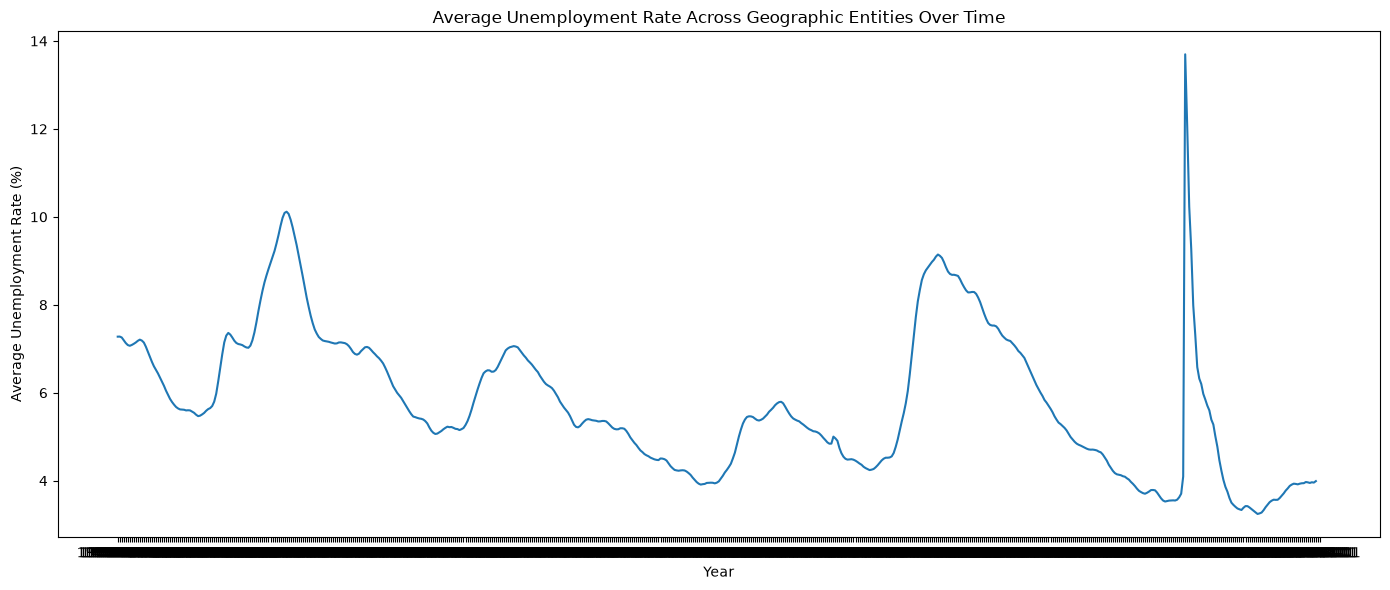

In [78]:
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("../outputs/figures/time_series")
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_avg["Date"],
    monthly_avg["Percent (%) of Labor Force Unemployed in State/Area"]
)

plt.title("Average Unemployment Rate Across Geographic Entities Over Time")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()

plt.savefig(
    output_dir / "monthly_unemployment_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
# Convert the Date column to pandas datetime format.
monthly_avg["Date"] = pd.to_datetime(monthly_avg["Date"])

# Verify the conversion.
print(monthly_avg["Date"].dtype)

datetime64[us]


In [81]:
# Calculate the average unemployment rate for each year.
annual_avg = (
    monthly_avg
    .assign(Year=monthly_avg["Date"].dt.year)
    .groupby("Year")[
        "Percent (%) of Labor Force Unemployed in State/Area"
    ]
    .mean()
    .reset_index()
)

annual_avg.head()

,Year,Percent (%) of Labor Force Unemployed in State/Area
0,1976,7.168239
1,1977,6.678616
2,1978,5.729874
3,1979,5.564780
4,1980,6.848742


In [82]:
# Check that the annual dataset contains one row for each year.
print(annual_avg.shape)
print(annual_avg["Year"].min(), annual_avg["Year"].max())

(50, 2)
1976 2025


In [83]:
# Identify the 10 years with the highest average unemployment rates.
highest_years = annual_avg.nlargest(
    10,
    "Percent (%) of Labor Force Unemployed in State/Area"
)

highest_years

,Year,Percent (%) of Labor Force Unemployed in State/Area
6,1982,9.201101
7,1983,9.166352
34,2010,8.823270
33,2009,8.527987
35,2011,8.213522
44,2020,7.590409
36,2012,7.429403
5,1981,7.299528
8,1984,7.297799
0,1976,7.168239


In [84]:
# Identify the 10 years with the lowest average unemployment rates.
lowest_years = annual_avg.nsmallest(
    10,
    "Percent (%) of Labor Force Unemployed in State/Area"
)

lowest_years

,Year,Percent (%) of Labor Force Unemployed in State/Area
47,2023,3.377516
46,2022,3.448585
43,2019,3.596226
48,2024,3.772799
42,2018,3.798428
24,2000,3.945597
49,2025,3.966792
41,2017,4.182233
23,1999,4.191038
31,2007,4.364780


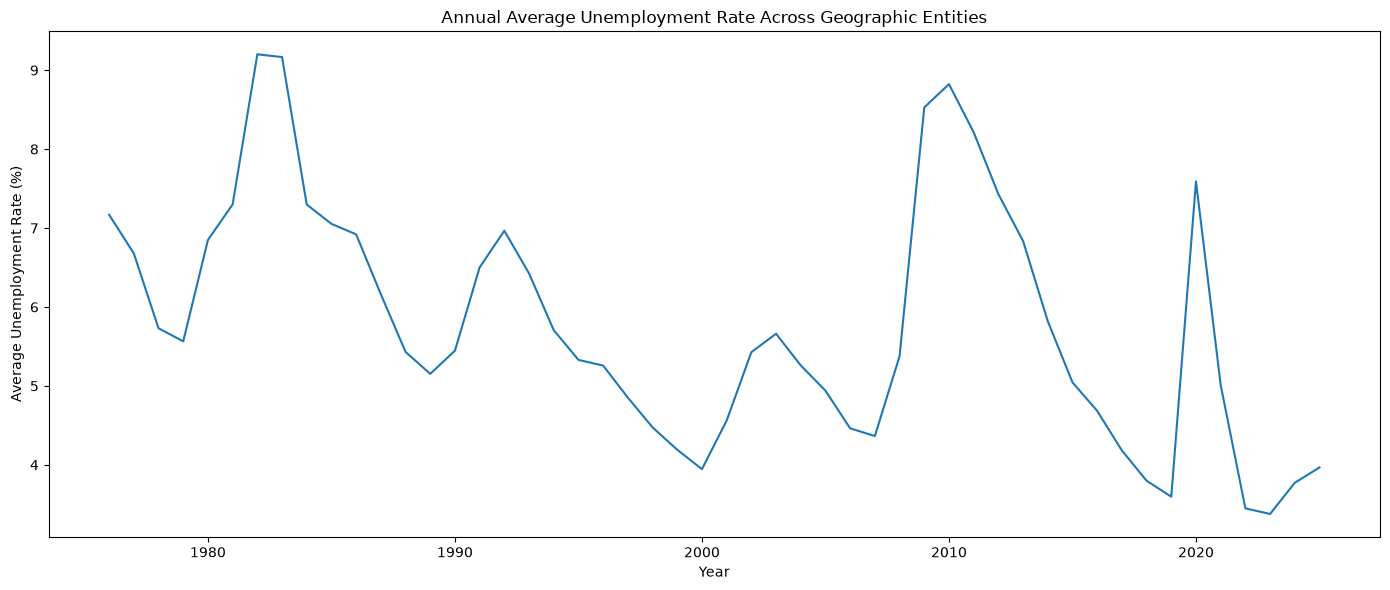

In [85]:
# Plot the annual average unemployment rate to show long-term trends.
plt.figure(figsize=(14, 6))

plt.plot(
    annual_avg["Year"],
    annual_avg["Percent (%) of Labor Force Unemployed in State/Area"]
)

plt.title("Annual Average Unemployment Rate Across Geographic Entities")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()

# Save the annual trend figure for the project outputs.
plt.savefig(
    output_dir / "annual_unemployment_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Time-Series Analysis — Insights

The annual analysis reveals several distinct periods of unemployment variation:

1982–1983 recorded the highest annual average unemployment rates, at 9.20% and 9.17%.

The 2009–2012 period also showed persistently elevated unemployment, peaking at 8.82% in 2010.

2020 had an annual average of 7.59%, despite containing the highest monthly unemployment shock in the dataset.

2022–2024 recorded the lowest complete-year averages, with 2023 reaching 3.38%.

Overall, the data suggests that some historical periods experienced prolonged unemployment, while COVID-19 produced a sharp but relatively short-lived shock.

In [86]:
# Compare average unemployment before, during, and after the COVID-19 shock.
covid_period = annual_avg[
    annual_avg["Year"].isin([2019, 2020, 2021, 2022])
]

covid_period

,Year,Percent (%) of Labor Force Unemployed in State/Area
43,2019,3.596226
44,2020,7.590409
45,2021,5.012107
46,2022,3.448585


In [87]:
# Calculate the annual percentage-point changes during the COVID period.
covid_period = covid_period.copy()

covid_period["Change (percentage points)"] = (
    covid_period[
        "Percent (%) of Labor Force Unemployed in State/Area"
    ].diff()
)

covid_period

,Year,Percent (%) of Labor Force Unemployed in State/Area,Change (percentage points)
43,2019,3.596226,NaN
44,2020,7.590409,3.994182
45,2021,5.012107,-2.578302
46,2022,3.448585,-1.563522


In [88]:
# Compare the 2019 baseline with the highest monthly unemployment rate.
pre_covid_avg = monthly_avg.loc[
    monthly_avg["Date"].dt.year == 2019,
    "Percent (%) of Labor Force Unemployed in State/Area"
].mean()

covid_peak = monthly_avg.loc[
    monthly_avg["Percent (%) of Labor Force Unemployed in State/Area"].idxmax()
]

peak_increase = (
    covid_peak["Percent (%) of Labor Force Unemployed in State/Area"]
    - pre_covid_avg
)

print(f"2019 monthly average: {pre_covid_avg:.2f}%")
print(f"COVID peak: {covid_peak['Date'].strftime('%B %Y')} "
      f"({covid_peak['Percent (%) of Labor Force Unemployed in State/Area']:.2f}%)")
print(f"Increase from 2019 baseline: {peak_increase:.2f} percentage points")

2019 monthly average: 3.60%
COVID peak: April 2020 (13.70%)
Increase from 2019 baseline: 10.10 percentage points


In [89]:
# Calculate each geographic entity's average unemployment rate during 2020.
covid_by_area = (
    df[df["Year"] == 2020]
    .groupby("State/Area")[
        "Percent (%) of Labor Force Unemployed in State/Area"
    ]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

covid_by_area.head(10)

,State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,Nevada,13.675000
1,New York city,12.391667
2,Los Angeles County,12.333333
3,Hawaii,11.741667
4,California,10.166667
5,Michigan,10.075000
6,New York,9.908333
7,New Jersey,9.483333
8,Massachusetts,9.341667
9,Illinois,9.333333


In [90]:
# Measure each area's unemployment increase from 2019 to 2020.
area_covid_change = (
    df[df["Year"].isin([2019, 2020])]
    .groupby(["State/Area", "Year"])[
        "Percent (%) of Labor Force Unemployed in State/Area"
    ]
    .mean()
    .unstack()
)

area_covid_change["Change (percentage points)"] = (
    area_covid_change[2020] - area_covid_change[2019]
)

area_covid_change = (
    area_covid_change
    .sort_values("Change (percentage points)", ascending=False)
    .reset_index()
)

area_covid_change.head(10)

Year,State/Area,2019,2020,Change (percentage points)
0,Nevada,4.108333,13.675000,9.566667
1,Hawaii,2.508333,11.741667,9.233333
2,New York city,3.975000,12.391667,8.416667
3,Los Angeles County,4.500000,12.333333,7.833333
4,Massachusetts,3.050000,9.341667,6.291667
5,California,4.091667,10.166667,6.075000
6,New Jersey,3.458333,9.483333,6.025000
7,New York,3.891667,9.908333,6.016667
8,Michigan,4.075000,10.075000,6.000000
9,Rhode Island,3.525000,9.258333,5.733333


COVID-19 Impact Analysis — Insights

The COVID-19 period produced an exceptionally sharp but relatively short-term increase in unemployment.


Average unemployment increased from 3.60% in 2019 to 7.59% in 2020, a rise of 3.99 percentage points.

The highest monthly average occurred in April 2020 at 13.70%, representing a 10.10-percentage-point increase from the 2019 monthly baseline.

Unemployment declined to 5.01% in 2021 and 3.45% in 2022, indicating a substantial recovery after the initial shock.

The impact varied considerably across geographic entities. Nevada experienced the largest 2019–2020 increase (9.57 percentage points), followed by Hawaii (9.23 points) and New York City (8.42 points).

The results indicate that COVID-19 created the strongest short-term unemployment shock in the dataset, while its annual impact was less prolonged than the elevated unemployment periods observed in the early 1980s and after the 2008 financial crisis.

In [91]:
# Calculate the average unemployment rate for each calendar month.
monthly_seasonality = (
    df.groupby("Month")[
        "Percent (%) of Labor Force Unemployed in State/Area"
    ]
    .mean()
    .reset_index()
)

monthly_seasonality

,Month,Percent (%) of Labor Force Unemployed in State/Area
0,1,5.757245
1,2,5.745472
2,3,5.740189
3,4,5.920491
4,5,5.875019
5,6,5.831094
6,7,5.802755
7,8,5.769283
8,9,5.752000
9,10,5.766153


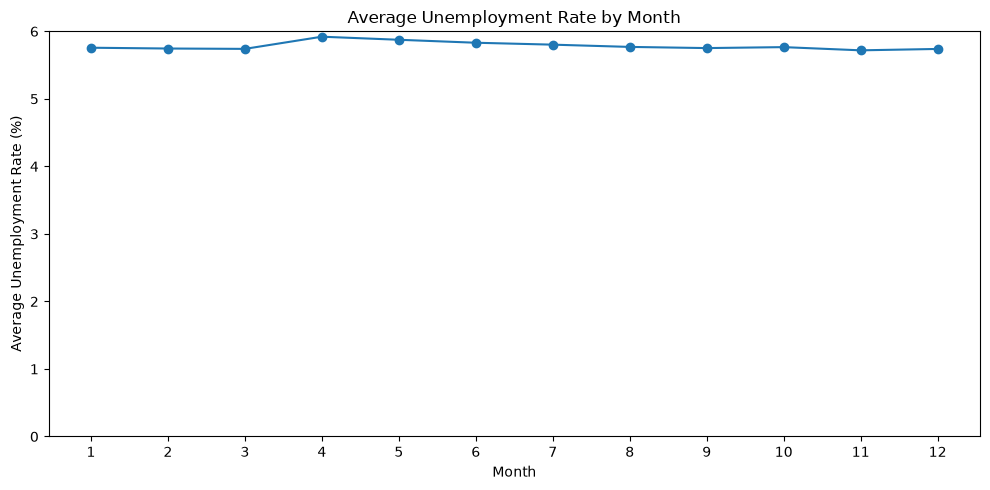

In [93]:
# Plot monthly unemployment using a zero-based y-axis to show the true scale.
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_seasonality["Month"],
    monthly_seasonality["Percent (%) of Labor Force Unemployed in State/Area"],
    marker="o"
)

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(range(1, 13))
plt.ylim(0, 6)

plt.tight_layout()

# Save the corrected seasonal analysis figure.
seasonal_output_dir = Path("../outputs/figures/seasonal_analysis")
seasonal_output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    seasonal_output_dir / "monthly_seasonality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Seasonal Analysis — Insights

The monthly averages show limited seasonal variation in unemployment:

April has the highest average unemployment rate at 5.92%.
November has the lowest at 5.72%.
The overall difference is only about 0.20 percentage points.
Therefore, the dataset does not indicate a strong overall seasonal pattern in unemployment.

In [94]:
# Calculate the long-term average unemployment rate for each geographic entity.
area_avg = (
    df.groupby("State/Area")[
        "Percent (%) of Labor Force Unemployed in State/Area"
    ]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

area_avg.head(10)

,State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,West Virginia,7.660870
1,New York city,7.621906
2,Michigan,7.577926
3,Alaska,7.529933
4,Los Angeles County,7.350167
5,District of Columbia,7.313712
6,Mississippi,7.106522
7,California,7.104013
8,Louisiana,6.827592
9,Illinois,6.722910


In [95]:
# Identify the geographic entities with the lowest long-term unemployment rates.
area_avg.tail(10)

,State/Area,Percent (%) of Labor Force Unemployed in State/Area
43,Minnesota,4.664381
44,Utah,4.592642
45,Kansas,4.513043
46,Virginia,4.491806
47,Iowa,4.445819
48,Vermont,4.357525
49,New Hampshire,4.131438
50,North Dakota,3.653846
51,South Dakota,3.482776
52,Nebraska,3.395485


In [96]:
# Summarize unemployment variability within each geographic entity.
area_stats = (
    df.groupby("State/Area")[
        "Percent (%) of Labor Force Unemployed in State/Area"
    ]
    .agg(["mean", "min", "max", "std"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

area_stats.head(10)

,State/Area,mean,min,max,std
50,West Virginia,7.660870,3.5,18.3,3.010630
34,New York city,7.621906,3.8,21.5,2.261743
23,Michigan,7.577926,3.2,22.7,3.083557
1,Alaska,7.529933,3.8,11.7,1.675378
18,Los Angeles County,7.350167,4.2,18.8,2.333291
8,District of Columbia,7.313712,4.0,11.3,1.572240
25,Mississippi,7.106522,2.8,15.6,2.151726
4,California,7.104013,3.8,16.1,2.165865
19,Louisiana,6.827592,3.5,13.5,2.207948
13,Illinois,6.722910,3.6,18.3,2.085266


In [97]:
# Identify the most and least volatile geographic entities.
highest_volatility = area_stats.nlargest(10, "std")
lowest_volatility = area_stats.nsmallest(10, "std")

highest_volatility[["State/Area", "std"]], lowest_volatility[["State/Area", "std"]]

(            State/Area       std
 23            Michigan  3.083557
 50       West Virginia  3.010630
 29              Nevada  2.760362
 0              Alabama  2.671914
 41        Rhode Island  2.385381
 14             Indiana  2.348922
 18  Los Angeles County  2.333291
 34       New York city  2.261743
 19           Louisiana  2.207948
 37                Ohio  2.180517,
       State/Area       std
 28      Nebraska  0.886978
 43  South Dakota  0.916399
 36  North Dakota  1.048095
 16        Kansas  1.095658
 48      Virginia  1.363665
 24     Minnesota  1.437014
 21      Maryland  1.439170
 52       Wyoming  1.439201
 38      Oklahoma  1.455962
 45         Texas  1.468302)

Geographic Variability — Insights

The geographic variability analysis shows that unemployment differs substantially across areas in both average level and stability over time.


Michigan (3.08 pp) and West Virginia (3.01 pp) had the highest unemployment volatility, indicating larger fluctuations throughout the study period.

Nebraska (0.89 pp) and South Dakota (0.92 pp) had the lowest volatility, suggesting more stable unemployment conditions.

High average unemployment does not necessarily mean high volatility. For example, Alaska had a relatively high average unemployment rate (7.53%) but a lower standard deviation (1.68 pp).

Overall, geographic differences are driven by both persistent unemployment levels and the degree of fluctuation over time, making both measures important when comparing areas.

In [98]:
# Measure the relationship between labor-force participation and unemployment.
correlation = df[
    [
        "Percent (%) of State/Area's Population",
        "Percent (%) of Labor Force Unemployed in State/Area"
    ]
].corr()

correlation

,Percent (%) of State/Area's Population,Percent (%) of Labor Force Unemployed in State/Area
Percent (%) of State/Area's Population,1.000000,-0.300702
Percent (%) of Labor Force Unemployed in State/Area,-0.300702,1.000000


In [99]:
# Calculate year-to-year changes in the annual unemployment rate.
annual_changes = annual_avg.copy()
annual_changes["Change (percentage points)"] = (
    annual_changes[
        "Percent (%) of Labor Force Unemployed in State/Area"
    ].diff()
)

largest_increases = annual_changes.nlargest(
    10, "Change (percentage points)"
)

largest_decreases = annual_changes.nsmallest(
    10, "Change (percentage points)"
)

largest_increases, largest_decreases

(    Year  Percent (%) of Labor Force Unemployed in State/Area  \
 44  2020                                           7.590409     
 33  2009                                           8.527987     
 6   1982                                           9.201101     
 4   1980                                           6.848742     
 15  1991                                           6.501730     
 32  2008                                           5.376572     
 26  2002                                           5.427516     
 25  2001                                           4.560535     
 16  1992                                           6.965881     
 5   1981                                           7.299528     
 
     Change (percentage points)  
 44                    3.994182  
 33                    3.151415  
 6                     1.901572  
 4                     1.283962  
 15                    1.055346  
 32                    1.011792  
 26                    0.866981  


Major Historical Changes — Insights

The year-to-year analysis highlights several major shifts in unemployment:

2020 recorded the largest annual increase, rising 3.99 percentage points from 2019, confirming the exceptional impact of COVID-19.

The 2009 increase of 3.15 points was the second largest, reflecting the severe labor-market impact of the Great Recession period.

The early 1980s also experienced substantial increases, particularly 1982 (+1.90 points).
2021 recorded the largest annual decrease, falling 2.58 percentage points as the labor market recovered from the COVID shock.

Other notable recoveries occurred in 1984 (-1.87 points) and 2022 (-1.56 points).


Overall, the largest increases and decreases correspond to major economic disruption and recovery periods, reinforcing the importance of economic-cycle analysis in understanding unemployment trends.

In [101]:
# Calculate the average unemployment rate for the main historical periods.
periods = {
    "Early 1980s": range(1981, 1985),
    "Great Recession": range(2008, 2013),
    "COVID-19": range(2020, 2021),
    "Recent Low Period": range(2022, 2025)
}

period_summary = []

for period, years in periods.items():
    avg_rate = annual_avg[
        annual_avg["Year"].isin(years)
    ]["Percent (%) of Labor Force Unemployed in State/Area"].mean()

    period_summary.append([period, avg_rate])

period_summary = pd.DataFrame(
    period_summary,
    columns=["Period", "Average Unemployment"]
)

period_summary

,Period,Average Unemployment
0,Early 1980s,8.241195
1,Great Recession,7.674151
2,COVID-19,7.590409
3,Recent Low Period,3.532966


Historical Period Comparison — Insights

The comparison of major historical periods highlights a clear difference between prolonged unemployment periods and the COVID-19 shock:

The early 1980s had the highest period average at 8.24%, reflecting sustained elevated unemployment across several years.

The Great Recession period (2008–2012) averaged 7.67%, also showing prolonged unemployment.

COVID-19 (2020) averaged 7.59%. Although its annual average was slightly lower, it produced the largest short-term monthly shock in the dataset.

The recent low-unemployment period (2022–2024) averaged only 3.53%, substantially below the major historical periods.

Overall, the analysis shows that economic downturns can differ in duration and intensity: the early 1980s and Great Recession produced prolonged elevated unemployment, while COVID-19 produced an unusually sharp short-term shock followed by rapid recovery.

## Final EDA Summary

The exploratory data analysis revealed several important patterns in unemployment across geographic entities and over time.

### 1. Overall Unemployment

* The mean unemployment rate was **5.78%**, while the median was **5.40%**.
* Unemployment ranged from **1.7% to 30.5%**, showing substantial variation across the dataset.
* Most observations were concentrated between **4.2% and 7.0%**.

### 2. Historical Trends

* The highest annual average unemployment occurred in **1982 (9.20%)**, followed closely by **1983 (9.17%)**.
* Unemployment was also elevated during **2009–2012**, reaching **8.82% in 2010**.
* The lowest annual average occurred in **2023 (3.38%)**, followed by **2022 (3.45%)**.

### 3. COVID-19 Impact

* Average unemployment increased from **3.60% in 2019 to 7.59% in 2020**, an increase of **3.99 percentage points**.
* The highest monthly average occurred in **April 2020 at 13.70%**, which was **10.10 percentage points above the 2019 monthly baseline**.
* Unemployment declined to **5.01% in 2021** and **3.45% in 2022**, showing a strong recovery.
* **Nevada** experienced the largest 2019–2020 increase, at **9.57 percentage points**.

### 4. Seasonal Patterns

* Monthly unemployment showed **limited seasonal variation**.
* The highest monthly average was **April (5.92%)**, while the lowest was **November (5.72%)**.
* The difference of approximately **0.20 percentage points** indicates that there was **no strong overall seasonal pattern**.

### 5. Geographic Differences

* **West Virginia** had the highest long-term average unemployment rate at **7.66%**.
* **Nebraska** had the lowest at **3.40%**.
* This demonstrates substantial differences in unemployment conditions across geographic entities.

### 6. Geographic Variability

* **Michigan (3.08 pp)** and **West Virginia (3.01 pp)** had the highest unemployment volatility.
* **Nebraska (0.89 pp)** and **South Dakota (0.92 pp)** had the lowest volatility.
* Therefore, geographic differences involve both **average unemployment levels and stability over time**.

### 7. Relationship Between Labor-Force Participation and Unemployment

* The correlation between labor-force participation and unemployment was **-0.30**.
* This indicates a **weak-to-moderate negative linear relationship**: higher labor-force participation tends to be associated with somewhat lower unemployment.
* However, the relationship is not strong enough to explain unemployment differences on its own.

### 8. Major Historical Periods

The average unemployment rate across major periods was:

| Period          | Average Unemployment |
| --------------- | -------------------: |
| Early 1980s     |            **8.24%** |
| Great Recession |            **7.67%** |
| COVID-19        |            **7.59%** |
| 2022–2024       |            **3.53%** |

The results show that major economic disruptions differed in **duration and intensity**. The early 1980s and Great Recession were characterized by prolonged elevated unemployment, while COVID-19 produced an exceptionally sharp short-term shock followed by a rapid recovery.

### Overall Finding

Overall, unemployment in the dataset varies substantially across **time and geography**. Major economic events such as the **early-1980s recession, the Great Recession, and COVID-19** produced noticeable increases, while unemployment reached historically low levels during **2022–2024**. COVID-19 stands out as the most pronounced short-term shock, whereas the seasonal analysis indicates that **monthly seasonality was relatively weak**.
